In [3]:
# ============================================================
# NewsTopic-AI
# Task 5: Topic Modeling on News Articles
# Step 1: Load BBC News Dataset
# ============================================================

!pip -q install datasets

from datasets import load_dataset
import pandas as pd

# Load BBC News dataset
dataset = load_dataset("SetFit/bbc-news")

# Convert training split to DataFrame
df = dataset["train"].to_pandas()

# Rename columns for a clean project structure
df = df.rename(columns={
    "text": "text",
    "label": "label"
})

print("Dataset loaded successfully.")
print(f"Total articles: {len(df):,}")
print(f"Columns: {list(df.columns)}")

print("\nDataset shape:")
print(df.shape)

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

print("\nSample article:")
print(df.iloc[0]["text"][:1000])

README.md:   0%|          | 0.00/880 [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/2.87M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.28M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1225 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset loaded successfully.
Total articles: 1,225
Columns: ['text', 'label', 'label_text']

Dataset shape:
(1225, 3)

Label distribution:
label
0    212
1    286
2    275
3    210
4    242
Name: count, dtype: int64

Sample article:
wales want rugby league training wales could follow england s lead by training with a rugby league club.  england have already had a three-day session with leeds rhinos  and wales are thought to be interested in a similar clinic with rivals st helens. saints coach ian millward has given his approval  but if it does happen it is unlikely to be this season. saints have a week s training in portugal next week  while wales will play england in the opening six nations match on 5 february.  we have had an approach from wales   confirmed a saints spokesman.  it s in the very early stages but it is something we are giving serious consideration to.  st helens  who are proud of their welsh connections  are obvious partners for the welsh rugby union  despite a spat in

NEWS TOPIC AI - DATASET OVERVIEW

Total articles: 2,126
Duplicates removed: 99

Dataset shape:
(2126, 5)

Categories:
category
sport            504
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

Missing values:
text          0
label         0
category      0
word_count    0
char_count    0
dtype: int64

Text statistics:
       word_count  char_count
count     2126.00     2126.00
mean       390.45     2262.77
std        245.12     1382.01
min         90.00      501.00
25%        249.00     1437.50
50%        336.50     1956.50
75%        479.00     2801.50
max       4492.00    25483.00

Sample categories:
        category                                               text
0          sport  wales want rugby league training wales could f...
1       business  china aviation seeks rescue deal scandal-hit j...
2  entertainment  rock band u2 break ticket record u2 have smash...


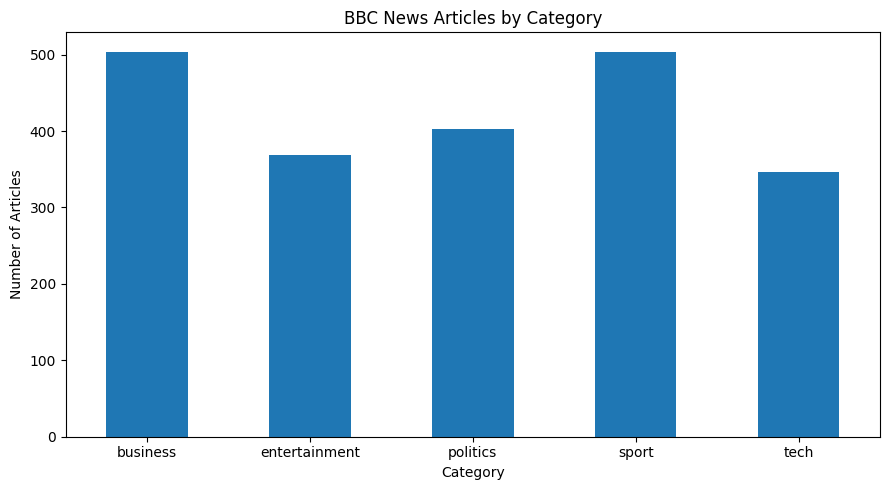

In [4]:
# ============================================================
# NewsTopic-AI
# Step 2: Combine Dataset + Initial EDA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Convert both splits to DataFrames
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

# Combine all articles
df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

# Keep only the columns we need
df = df[["text", "label", "label_text"]].copy()

# Rename category column for clarity
df = df.rename(columns={
    "label_text": "category"
})

# Remove possible duplicates
before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

after_duplicates = len(df)

# Basic text statistics
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

print("=" * 60)
print("NEWS TOPIC AI - DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal articles: {len(df):,}")
print(f"Duplicates removed: {before_duplicates - after_duplicates:,}")

print("\nDataset shape:")
print(df.shape)

print("\nCategories:")
print(df["category"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nText statistics:")
print(df[["word_count", "char_count"]].describe().round(2))

print("\nSample categories:")
print(df[["category", "text"]].head(3))

# Category distribution visualization
plt.figure(figsize=(9, 5))

df["category"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("BBC News Articles by Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# NewsTopic-AI
# Step 3: NLP Text Preprocessing
# ============================================================

!pip -q install nltk

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Initialize NLP tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    """
    Clean and normalize an article for topic modeling.
    """

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords and short tokens
    tokens = [
        word
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)


# Apply preprocessing
print("Preprocessing articles...")

df["clean_text"] = df["text"].apply(preprocess_text)

print("Preprocessing completed.")

# Remove articles that became empty after preprocessing
before_empty = len(df)

df = df[
    df["clean_text"].str.strip().str.len() > 0
].reset_index(drop=True)

removed_empty = before_empty - len(df)

print(f"\nArticles removed after preprocessing: {removed_empty}")
print(f"Final articles: {len(df):,}")

# Show before/after example
print("\n" + "=" * 60)
print("PREPROCESSING EXAMPLE")
print("=" * 60)

print("\nORIGINAL TEXT:")
print(df.iloc[0]["text"][:700])

print("\nCLEAN TEXT:")
print(df.iloc[0]["clean_text"][:700])

# Add cleaned word count
df["clean_word_count"] = df["clean_text"].str.split().str.len()

print("\nClean text statistics:")
print(df["clean_word_count"].describe().round(2))

Preprocessing articles...
Preprocessing completed.

Articles removed after preprocessing: 0
Final articles: 2,126

PREPROCESSING EXAMPLE

ORIGINAL TEXT:
wales want rugby league training wales could follow england s lead by training with a rugby league club.  england have already had a three-day session with leeds rhinos  and wales are thought to be interested in a similar clinic with rivals st helens. saints coach ian millward has given his approval  but if it does happen it is unlikely to be this season. saints have a week s training in portugal next week  while wales will play england in the opening six nations match on 5 february.  we have had an approach from wales   confirmed a saints spokesman.  it s in the very early stages but it is something we are giving serious consideration to.  st helens  who are proud of their welsh connections

CLEAN TEXT:
wale want rugby league training wale could follow england lead training rugby league club england already three day session leeds rhi

In [6]:
# ============================================================
# NewsTopic-AI
# Step 4: Feature Engineering for Topic Modeling
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ------------------------------------------------------------
# 1. Count Vectorization
#    Used by LDA
# ------------------------------------------------------------

count_vectorizer = CountVectorizer(
    min_df=3,
    max_df=0.90,
    max_features=10000,
    ngram_range=(1, 2)
)

count_matrix = count_vectorizer.fit_transform(df["clean_text"])

# ------------------------------------------------------------
# 2. TF-IDF Vectorization
#    Used by NMF
# ------------------------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.90,
    max_features=10000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])

# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("DOCUMENT-TERM MATRICES")
print("=" * 60)

print("\nCount Matrix (LDA):")
print(f"Shape: {count_matrix.shape}")
print(f"Non-zero values: {count_matrix.nnz:,}")

print("\nTF-IDF Matrix (NMF):")
print(f"Shape: {tfidf_matrix.shape}")
print(f"Non-zero values: {tfidf_matrix.nnz:,}")

print("\nVocabulary sizes:")
print(f"Count vocabulary: {len(count_vectorizer.get_feature_names_out()):,}")
print(f"TF-IDF vocabulary: {len(tfidf_vectorizer.get_feature_names_out()):,}")

# ------------------------------------------------------------
# 4. Show sample vocabulary
# ------------------------------------------------------------

print("\nSample vocabulary:")
print(
    count_vectorizer
    .get_feature_names_out()[:50]
)

DOCUMENT-TERM MATRICES

Count Matrix (LDA):
Shape: (2126, 10000)
Non-zero values: 317,443

TF-IDF Matrix (NMF):
Shape: (2126, 10000)
Non-zero values: 317,443

Vocabulary sizes:
Count vocabulary: 10,000
TF-IDF vocabulary: 10,000

Sample vocabulary:
['aaa' 'aaa title' 'abandoned' 'abandoning' 'abba' 'abbas' 'abbasi'
 'abbott' 'abc' 'aberdeen' 'abeyie' 'abiding' 'ability' 'able'
 'able access' 'able get' 'able make' 'able play' 'able see' 'abn'
 'abn amro' 'abolish' 'abortion' 'abroad' 'absence' 'absent' 'absolute'
 'absolutely' 'abuse' 'abused' 'academic' 'academy' 'academy award'
 'accelerating' 'accept' 'acceptable' 'acceptance' 'accepted' 'accepting'
 'access' 'accessed' 'accessible' 'accessing' 'accident' 'acclaim'
 'acclaimed' 'accolade' 'accompanied' 'accomplished' 'according']


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.1 MB/s eta 0:00:00
LDA TOPIC NUMBER SELECTION

Documents: 2,126
Dictionary size: 10,792
Corpus documents: 2,126

Training LDA with 2 topics...
Topics:  2 | Coherence: 0.2548 | Log Perplexity: -8.1005

Training LDA with 3 topics...
Topics:  3 | Coherence: 0.3349 | Log Perplexity: -8.0758

Training LDA with 4 topics...
Topics:  4 | Coherence: 0.3899 | Log Perplexity: -8.0464

Training LDA with 5 topics...
Topics:  5 | Coherence: 0.4020 | Log Perplexity: -8.0259

Training LDA with 6 topics...
Topics:  6 | Coherence: 0.4037 | Log Perplexity: -8.0241

Training LDA with 7 topics...
Topics:  7 | Coherence: 0.4008 | Log Perplexity: -8.0199

Training LDA with 8 topics...
Topics:  8 | Coherence: 0.4187 | Log Perplexity: -8.0217

Training LDA with 9 topics...
Topics:  9 | Coherence: 0.4660 | Log Perplexity: -7.9906

Training LDA with 10 topics...
Topics: 10 | Coherence: 0.4214 | Log Perplexity: -8.0035

LDA MODEL SELECTION RESULTS


,num_topics,coherence,log_perplexity
0,2,0.2548,-8.1005
1,3,0.3349,-8.0758
2,4,0.3899,-8.0464
3,5,0.4020,-8.0259
4,6,0.4037,-8.0241
5,7,0.4008,-8.0199
6,8,0.4187,-8.0217
7,9,0.4660,-7.9906
8,10,0.4214,-8.0035



Best number of topics based on c_v coherence: 9
Best coherence score: 0.4660


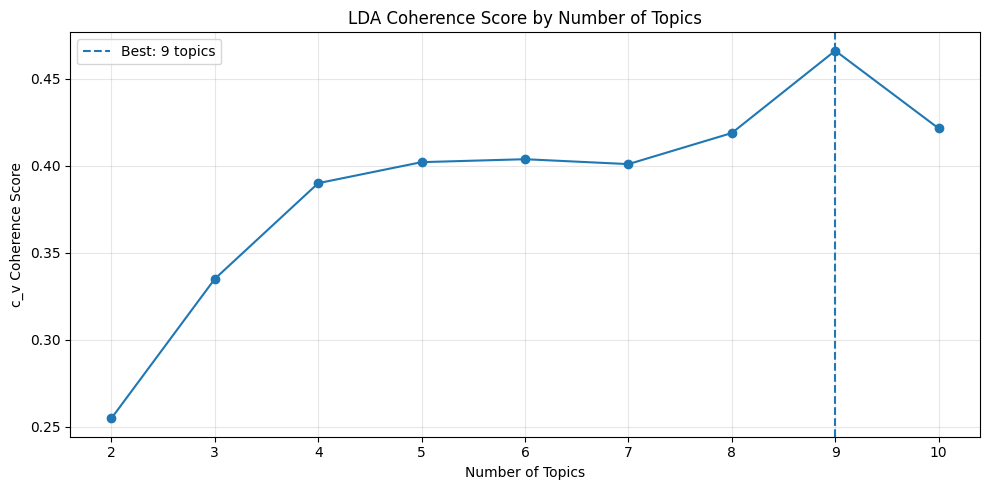

In [7]:
# ============================================================
# NewsTopic-AI
# Step 5: LDA Topic Number Selection
# ============================================================

!pip -q install gensim

import numpy as np
import matplotlib.pyplot as plt

from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# ------------------------------------------------------------
# Prepare tokenized documents for Gensim
# ------------------------------------------------------------

tokenized_documents = [
    text.split()
    for text in df["clean_text"]
]

# Create Gensim dictionary
dictionary = Dictionary(tokenized_documents)

# Remove very rare and extremely common terms
dictionary.filter_extremes(
    no_below=3,
    no_above=0.90
)

# Create Bag-of-Words corpus
corpus = [
    dictionary.doc2bow(tokens)
    for tokens in tokenized_documents
]

print("=" * 60)
print("LDA TOPIC NUMBER SELECTION")
print("=" * 60)

print(f"\nDocuments: {len(tokenized_documents):,}")
print(f"Dictionary size: {len(dictionary):,}")
print(f"Corpus documents: {len(corpus):,}")

# ------------------------------------------------------------
# Train LDA models for different topic counts
# ------------------------------------------------------------

topic_range = range(2, 11)

coherence_scores = []
perplexity_scores = []
lda_models = {}

for num_topics in topic_range:

    print(f"\nTraining LDA with {num_topics} topics...")

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100,
        alpha="auto",
        eta="auto"
    )

    # Coherence score
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=tokenized_documents,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = coherence_model.get_coherence()

    # Perplexity
    perplexity = lda_model.log_perplexity(corpus)

    coherence_scores.append(coherence)
    perplexity_scores.append(perplexity)
    lda_models[num_topics] = lda_model

    print(
        f"Topics: {num_topics:2d} | "
        f"Coherence: {coherence:.4f} | "
        f"Log Perplexity: {perplexity:.4f}"
    )

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

results = pd.DataFrame({
    "num_topics": list(topic_range),
    "coherence": coherence_scores,
    "log_perplexity": perplexity_scores
})

print("\n" + "=" * 60)
print("LDA MODEL SELECTION RESULTS")
print("=" * 60)

display(
    results.style
    .format({
        "coherence": "{:.4f}",
        "log_perplexity": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Best topic count
# ------------------------------------------------------------

best_num_topics = results.loc[
    results["coherence"].idxmax(),
    "num_topics"
]

best_coherence = results["coherence"].max()

print(
    f"\nBest number of topics based on c_v coherence: "
    f"{best_num_topics}"
)

print(f"Best coherence score: {best_coherence:.4f}")

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    results["num_topics"],
    results["coherence"],
    marker="o"
)

plt.axvline(
    best_num_topics,
    linestyle="--",
    label=f"Best: {best_num_topics} topics"
)

plt.title("LDA Coherence Score by Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("c_v Coherence Score")
plt.xticks(list(topic_range))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# NewsTopic-AI
# Step 6: Extract and Interpret LDA Topics
# ============================================================

# Get the best LDA model
best_lda_model = lda_models[best_num_topics]

# Number of top words to display
TOP_WORDS = 15

print("=" * 70)
print(f"LDA TOPIC INTERPRETATION — {best_num_topics} TOPICS")
print("=" * 70)

topic_data = []

for topic_id in range(best_num_topics):

    # Get top words and probabilities
    words = best_lda_model.show_topic(
        topic_id,
        topn=TOP_WORDS
    )

    word_list = [word for word, probability in words]
    probability_list = [probability for word, probability in words]

    topic_data.append({
        "topic_id": topic_id + 1,
        "top_words": ", ".join(word_list),
        "word_probabilities": probability_list
    })

    print(f"\nTopic {topic_id + 1}")
    print("-" * 70)

    for rank, (word, probability) in enumerate(words, start=1):
        print(
            f"{rank:2d}. {word:<20} "
            f"{probability:.4f}"
        )

# Create a clean summary DataFrame
topics_df = pd.DataFrame([
    {
        "Topic": item["topic_id"],
        "Top Words": item["top_words"]
    }
    for item in topic_data
])

print("\n" + "=" * 70)
print("TOPIC SUMMARY")
print("=" * 70)

display(topics_df)

LDA TOPIC INTERPRETATION — 9 TOPICS

Topic 1
----------------------------------------------------------------------
 1. game                 0.0156
 2. time                 0.0117
 3. said                 0.0098
 4. england              0.0084
 5. win                  0.0072
 6. back                 0.0066
 7. first                0.0064
 8. play                 0.0064
 9. year                 0.0062
10. one                  0.0060
11. hour                 0.0057
12. playing              0.0052
13. player               0.0051
14. would                0.0050
15. two                  0.0050

Topic 2
----------------------------------------------------------------------
 1. club                 0.0118
 2. said                 0.0115
 3. year                 0.0090
 4. would                0.0067
 5. united               0.0060
 6. time                 0.0051
 7. last                 0.0050
 8. new                  0.0045
 9. chelsea              0.0043
10. glazer               0.0042
11. 

,Topic,Top Words
0,1,"game, time, said, england, win, back, first, p..."
1,2,"club, said, year, would, united, time, last, n..."
2,3,"said, year, music, show, new, time, one, band,..."
3,4,"said, would, government, lord, law, court, tol..."
4,5,"film, award, best, year, star, prize, director..."
5,6,"said, people, game, mobile, phone, technology,..."
6,7,"said, labour, party, would, government, also, ..."
7,8,"said, patent, software, company, machine, new,..."
8,9,"said, market, year, share, firm, company, busi..."


In [9]:
# ============================================================
# NewsTopic-AI
# Step 7: Domain-Specific Stopword Refinement
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary

# ------------------------------------------------------------
# Common news-reporting words that are not useful
# for discovering meaningful topics.
# ------------------------------------------------------------

news_stopwords = {
    "said",
    "say",
    "says",
    "would",
    "could",
    "also",
    "one",
    "two",
    "three",
    "year",
    "years",
    "time",
    "new",
    "like",
    "get",
    "got",
    "make",
    "made",
    "way",
    "back",
    "first",
    "last",
    "people"
}

# Combine standard English stopwords with domain-specific ones
refined_stopwords = stop_words.union(news_stopwords)

# Recreate cleaned text with refined stopwords
def refine_text(text):
    tokens = text.split()

    tokens = [
        word
        for word in tokens
        if word not in refined_stopwords
    ]

    return " ".join(tokens)


df["refined_text"] = df["clean_text"].apply(refine_text)

# ------------------------------------------------------------
# Tokenize refined documents
# ------------------------------------------------------------

refined_documents = [
    text.split()
    for text in df["refined_text"]
]

# ------------------------------------------------------------
# Build refined Gensim dictionary
# ------------------------------------------------------------

refined_dictionary = Dictionary(refined_documents)

refined_dictionary.filter_extremes(
    no_below=3,
    no_above=0.90
)

refined_corpus = [
    refined_dictionary.doc2bow(tokens)
    for tokens in refined_documents
]

print("=" * 60)
print("REFINED LDA DATASET")
print("=" * 60)

print(f"\nDocuments: {len(refined_documents):,}")
print(f"Dictionary size: {len(refined_dictionary):,}")
print(f"Average words/article before refinement: "
      f"{df['clean_word_count'].mean():.2f}")

df["refined_word_count"] = (
    df["refined_text"]
    .str.split()
    .str.len()
)

print(
    f"Average words/article after refinement: "
    f"{df['refined_word_count'].mean():.2f}"
)

print("\nExample:")
print("\nBefore:")
print(df.iloc[0]["clean_text"][:500])

print("\nAfter:")
print(df.iloc[0]["refined_text"][:500])

REFINED LDA DATASET

Documents: 2,126
Dictionary size: 10,766
Average words/article before refinement: 212.38
Average words/article after refinement: 195.99

Example:

Before:
wale want rugby league training wale could follow england lead training rugby league club england already three day session leeds rhino wale thought interested similar clinic rival helen saint coach ian millward given approval happen unlikely season saint week training portugal next week wale play england opening six nation match february approach wale confirmed saint spokesman early stage something giving serious consideration helen proud welsh connection obvious partner welsh rugby union despi

After:
wale want rugby league training wale follow england lead training rugby league club england already day session leeds rhino wale thought interested similar clinic rival helen saint coach ian millward given approval happen unlikely season saint week training portugal next week wale play england opening six nation m

REFINED LDA TOPIC NUMBER SELECTION

Training refined LDA with 5 topics...
Topics:  5 | Coherence: 0.5815 | Log Perplexity: -8.1378

Training refined LDA with 6 topics...
Topics:  6 | Coherence: 0.5987 | Log Perplexity: -8.1254

Training refined LDA with 7 topics...
Topics:  7 | Coherence: 0.5398 | Log Perplexity: -8.1326

Training refined LDA with 8 topics...
Topics:  8 | Coherence: 0.4941 | Log Perplexity: -8.1510

Training refined LDA with 9 topics...
Topics:  9 | Coherence: 0.5090 | Log Perplexity: -8.1570

Training refined LDA with 10 topics...
Topics: 10 | Coherence: 0.4938 | Log Perplexity: -8.1669

Training refined LDA with 11 topics...
Topics: 11 | Coherence: 0.4718 | Log Perplexity: -8.1780

Training refined LDA with 12 topics...
Topics: 12 | Coherence: 0.4868 | Log Perplexity: -8.1798

REFINED LDA RESULTS


,num_topics,coherence,log_perplexity
0,5,0.5815,-8.1378
1,6,0.5987,-8.1254
2,7,0.5398,-8.1326
3,8,0.4941,-8.1510
4,9,0.5090,-8.1570
5,10,0.4938,-8.1669
6,11,0.4718,-8.1780
7,12,0.4868,-8.1798



Best refined number of topics: 6
Best refined coherence: 0.5987

BASELINE vs REFINED
Baseline coherence: 0.4660
Refined coherence:  0.5987
Improvement:        +0.1327


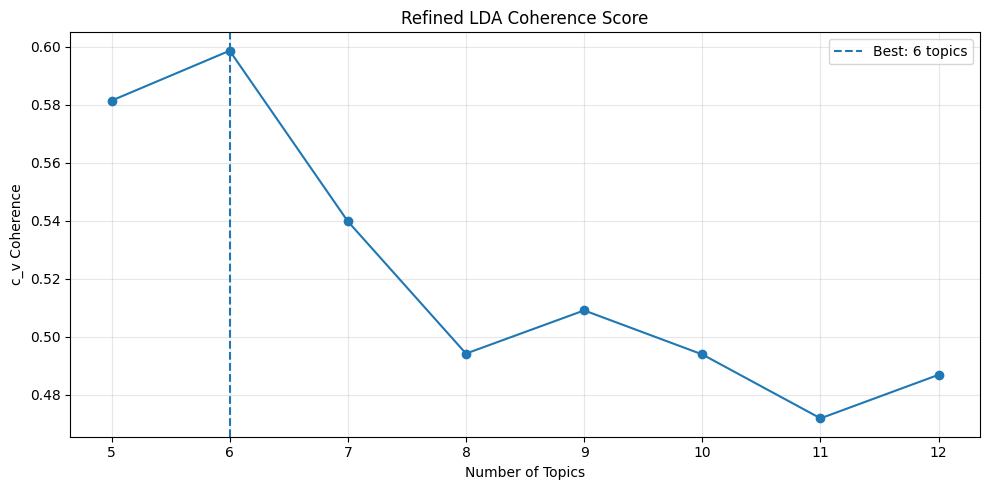

In [10]:
# ============================================================
# NewsTopic-AI
# Step 8: Refined LDA Model Selection
# ============================================================

from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# ------------------------------------------------------------
# Test a wider range around the baseline optimum
# ------------------------------------------------------------

refined_topic_range = range(5, 13)

refined_coherence_scores = []
refined_perplexity_scores = []
refined_lda_models = {}

print("=" * 60)
print("REFINED LDA TOPIC NUMBER SELECTION")
print("=" * 60)

for num_topics in refined_topic_range:

    print(f"\nTraining refined LDA with {num_topics} topics...")

    model = LdaModel(
        corpus=refined_corpus,
        id2word=refined_dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100,
        alpha="auto",
        eta="auto"
    )

    # Coherence
    coherence_model = CoherenceModel(
        model=model,
        texts=refined_documents,
        dictionary=refined_dictionary,
        coherence="c_v"
    )

    coherence = coherence_model.get_coherence()

    # Log perplexity
    perplexity = model.log_perplexity(refined_corpus)

    refined_coherence_scores.append(coherence)
    refined_perplexity_scores.append(perplexity)
    refined_lda_models[num_topics] = model

    print(
        f"Topics: {num_topics:2d} | "
        f"Coherence: {coherence:.4f} | "
        f"Log Perplexity: {perplexity:.4f}"
    )

# ------------------------------------------------------------
# Results DataFrame
# ------------------------------------------------------------

refined_results = pd.DataFrame({
    "num_topics": list(refined_topic_range),
    "coherence": refined_coherence_scores,
    "log_perplexity": refined_perplexity_scores
})

print("\n" + "=" * 60)
print("REFINED LDA RESULTS")
print("=" * 60)

display(
    refined_results.style.format({
        "coherence": "{:.4f}",
        "log_perplexity": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Best refined model
# ------------------------------------------------------------

refined_best_num_topics = int(
    refined_results.loc[
        refined_results["coherence"].idxmax(),
        "num_topics"
    ]
)

refined_best_coherence = refined_results["coherence"].max()

print(
    f"\nBest refined number of topics: "
    f"{refined_best_num_topics}"
)

print(
    f"Best refined coherence: "
    f"{refined_best_coherence:.4f}"
)

# ------------------------------------------------------------
# Compare with baseline
# ------------------------------------------------------------

baseline_coherence = best_coherence

improvement = refined_best_coherence - baseline_coherence

print("\n" + "=" * 60)
print("BASELINE vs REFINED")
print("=" * 60)

print(f"Baseline coherence: {baseline_coherence:.4f}")
print(f"Refined coherence:  {refined_best_coherence:.4f}")
print(f"Improvement:        {improvement:+.4f}")

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    refined_results["num_topics"],
    refined_results["coherence"],
    marker="o"
)

plt.axvline(
    refined_best_num_topics,
    linestyle="--",
    label=f"Best: {refined_best_num_topics} topics"
)

plt.title("Refined LDA Coherence Score")
plt.xlabel("Number of Topics")
plt.ylabel("c_v Coherence")
plt.xticks(list(refined_topic_range))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# NewsTopic-AI
# Step 9: Final LDA Topic Interpretation
# ============================================================

final_lda_model = refined_lda_models[refined_best_num_topics]

print("=" * 70)
print("FINAL LDA TOPICS")
print("=" * 70)

num_top_words = 15

final_topics = []

for topic_id in range(refined_best_num_topics):

    topic_words = final_lda_model.show_topic(
        topic_id,
        topn=num_top_words
    )

    words = [word for word, weight in topic_words]

    final_topics.append({
        "topic_id": topic_id + 1,
        "top_words": words,
        "word_weights": [weight for word, weight in topic_words]
    })

    print(f"\nTopic {topic_id + 1}")
    print("-" * 50)

    for rank, (word, weight) in enumerate(topic_words, start=1):
        print(f"{rank:2d}. {word:<20} {weight:.4f}")

print("\n" + "=" * 70)
print("TOPIC EXTRACTION COMPLETED")
print("=" * 70)

FINAL LDA TOPICS

Topic 1
--------------------------------------------------
 1. film                 0.0107
 2. best                 0.0070
 3. show                 0.0069
 4. world                0.0059
 5. award                0.0058
 6. music                0.0047
 7. star                 0.0041
 8. band                 0.0038
 9. day                  0.0038
10. top                  0.0036
11. play                 0.0035
12. edward               0.0033
13. game                 0.0032
14. album                0.0032
15. song                 0.0030

Topic 2
--------------------------------------------------
 1. game                 0.0265
 2. mobile               0.0147
 3. phone                0.0110
 4. technology           0.0104
 5. video                0.0059
 6. market               0.0056
 7. player               0.0049
 8. used                 0.0048
 9. digital              0.0047
10. play                 0.0045
11. device               0.0045
12. set                  0.0043

In [12]:
# ============================================================
# NewsTopic-AI
# Step 10: Human-Readable Topic Labels
# ============================================================

topic_labels = {
    0: "Film, Music & Entertainment",
    1: "Technology, Mobile & Gaming",
    2: "Politics & Government",
    3: "Sports & Football",
    4: "Software, Internet & Digital Technology",
    5: "Business & Financial Markets"
}

print("=" * 70)
print("FINAL TOPIC LABELS")
print("=" * 70)

for topic_id, label in topic_labels.items():
    print(f"Topic {topic_id + 1}: {label}")

print("\n" + "=" * 70)
print("Topic labels assigned successfully.")
print("=" * 70)

FINAL TOPIC LABELS
Topic 1: Film, Music & Entertainment
Topic 2: Technology, Mobile & Gaming
Topic 3: Politics & Government
Topic 4: Sports & Football
Topic 5: Software, Internet & Digital Technology
Topic 6: Business & Financial Markets

Topic labels assigned successfully.


In [13]:
# ============================================================
# NewsTopic-AI
# Step 11: Document Topic Distribution
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("DOCUMENT TOPIC DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# Get topic probabilities for every document
# ------------------------------------------------------------

document_topic_distributions = []

for document in refined_corpus:

    topic_distribution = final_lda_model.get_document_topics(
        document,
        minimum_probability=0
    )

    # Convert sparse topic distribution to ordered array
    topic_probabilities = np.zeros(
        refined_best_num_topics
    )

    for topic_id, probability in topic_distribution:
        topic_probabilities[topic_id] = probability

    document_topic_distributions.append(
        topic_probabilities
    )

document_topic_matrix = np.array(
    document_topic_distributions
)

print(f"\nDocuments: {document_topic_matrix.shape[0]:,}")
print(f"Topics:    {document_topic_matrix.shape[1]}")

# ------------------------------------------------------------
# Add topic probabilities to dataframe
# ------------------------------------------------------------

for topic_id in range(refined_best_num_topics):

    df[f"topic_{topic_id + 1}_probability"] = (
        document_topic_matrix[:, topic_id]
    )

# ------------------------------------------------------------
# Determine dominant topic
# ------------------------------------------------------------

dominant_topic_indices = np.argmax(
    document_topic_matrix,
    axis=1
)

df["dominant_topic"] = (
    dominant_topic_indices + 1
)

df["dominant_topic_label"] = [
    topic_labels[topic_id]
    for topic_id in dominant_topic_indices
]

df["dominant_topic_probability"] = (
    np.max(
        document_topic_matrix,
        axis=1
    )
)

# ------------------------------------------------------------
# Validate probability distributions
# ------------------------------------------------------------

probability_sums = (
    document_topic_matrix.sum(axis=1)
)

print("\nProbability validation:")
print(
    f"Minimum probability sum: "
    f"{probability_sums.min():.6f}"
)

print(
    f"Maximum probability sum: "
    f"{probability_sums.max():.6f}"
)

print(
    f"All distributions sum to 1: "
    f"{np.allclose(probability_sums, 1.0)}"
)

# ------------------------------------------------------------
# Topic distribution summary
# ------------------------------------------------------------

topic_distribution_summary = (
    df["dominant_topic_label"]
    .value_counts()
    .rename_axis("topic")
    .reset_index(name="article_count")
)

topic_distribution_summary["percentage"] = (
    topic_distribution_summary["article_count"]
    / len(df)
    * 100
)

topic_distribution_summary = (
    topic_distribution_summary
    .sort_values(
        "article_count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("ARTICLES BY DOMINANT TOPIC")
print("=" * 70)

display(
    topic_distribution_summary.style.format({
        "percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Preview classified articles
# ------------------------------------------------------------

preview_columns = [
    "category",
    "dominant_topic",
    "dominant_topic_label",
    "dominant_topic_probability"
]

print("\n" + "=" * 70)
print("ARTICLE TOPIC ASSIGNMENT PREVIEW")
print("=" * 70)

display(
    df[
        preview_columns
    ].head(10)
)

print("\n" + "=" * 70)
print("DOCUMENT TOPIC DISTRIBUTION COMPLETED")
print("=" * 70)

DOCUMENT TOPIC DISTRIBUTION

Documents: 2,126
Topics:    6

Probability validation:
Minimum probability sum: 1.000000
Maximum probability sum: 1.000000
All distributions sum to 1: True

ARTICLES BY DOMINANT TOPIC


,topic,article_count,percentage
0,Business & Financial Markets,540,25.40%
1,Sports & Football,474,22.30%
2,"Film, Music & Entertainment",385,18.11%
3,Politics & Government,369,17.36%
4,"Software, Internet & Digital Technology",194,9.13%
5,"Technology, Mobile & Gaming",164,7.71%



ARTICLE TOPIC ASSIGNMENT PREVIEW


,category,dominant_topic,dominant_topic_label,dominant_topic_probability
0,sport,4,Sports & Football,0.815173
1,business,6,Business & Financial Markets,0.978557
2,entertainment,1,"Film, Music & Entertainment",0.623694
3,business,6,Business & Financial Markets,0.789209
4,tech,5,"Software, Internet & Digital Technology",0.348659
5,politics,5,"Software, Internet & Digital Technology",0.508451
6,entertainment,1,"Film, Music & Entertainment",0.792396
7,entertainment,1,"Film, Music & Entertainment",0.718178
8,politics,3,Politics & Government,0.866631
9,business,6,Business & Financial Markets,0.600035



DOCUMENT TOPIC DISTRIBUTION COMPLETED


TOPIC DISTRIBUTION ANALYSIS

FINAL TOPIC SUMMARY


,dominant_topic,dominant_topic_label,article_count,average_confidence,percentage
0,1,"Film, Music & Entertainment",385,0.7302,18.11%
1,2,"Technology, Mobile & Gaming",164,0.5834,7.71%
2,3,Politics & Government,369,0.6714,17.36%
3,4,Sports & Football,474,0.8207,22.30%
4,5,"Software, Internet & Digital Technology",194,0.5948,9.13%
5,6,Business & Financial Markets,540,0.7447,25.40%


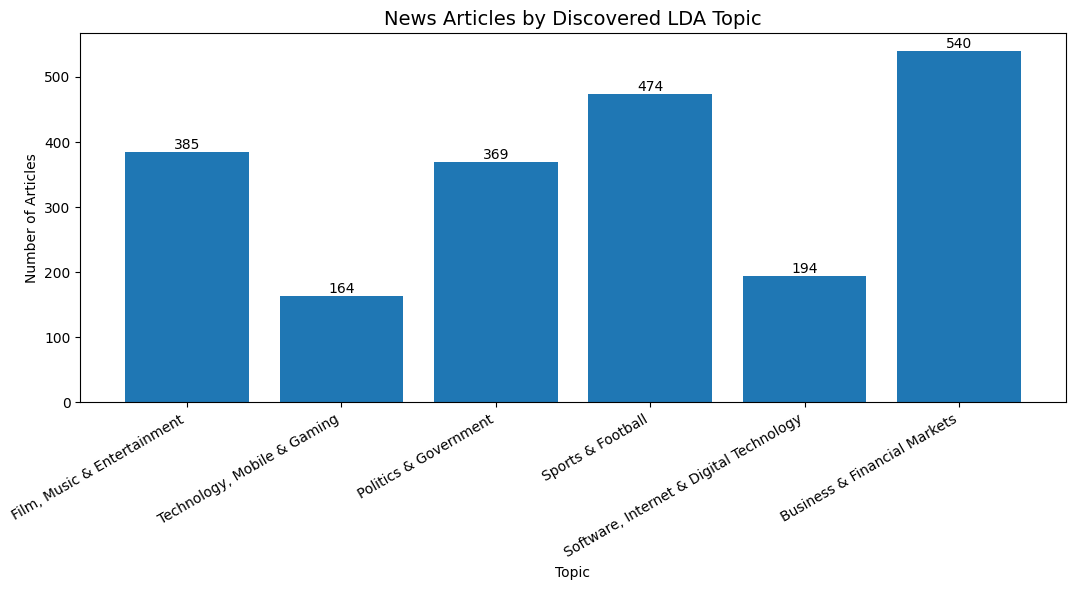

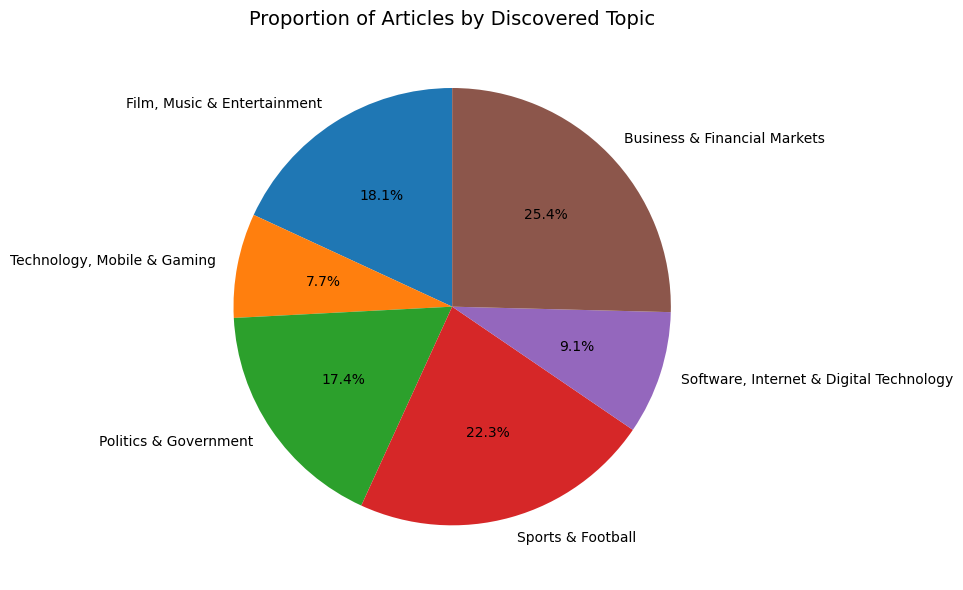


TOPIC ASSIGNMENT CONFIDENCE
Mean dominant-topic probability: 0.7202
Median dominant-topic probability: 0.7377

TOPIC DISTRIBUTION ANALYSIS COMPLETED


In [14]:
# ============================================================
# NewsTopic-AI
# Step 12: Topic Distribution Analysis
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print("TOPIC DISTRIBUTION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Reorder topics by topic ID for consistent visualization
# ------------------------------------------------------------

topic_summary = (
    df.groupby(
        ["dominant_topic", "dominant_topic_label"],
        as_index=False
    )
    .agg(
        article_count=("dominant_topic", "size"),
        average_confidence=(
            "dominant_topic_probability",
            "mean"
        )
    )
)

topic_summary["percentage"] = (
    topic_summary["article_count"]
    / len(df)
    * 100
)

topic_summary = topic_summary.sort_values(
    "dominant_topic"
).reset_index(drop=True)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TOPIC SUMMARY")
print("=" * 70)

display(
    topic_summary.style.format({
        "average_confidence": "{:.4f}",
        "percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Topic distribution visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

bars = plt.bar(
    topic_summary["dominant_topic_label"],
    topic_summary["article_count"]
)

plt.title(
    "News Articles by Discovered LDA Topic",
    fontsize=14
)

plt.xlabel("Topic")
plt.ylabel("Number of Articles")

plt.xticks(
    rotation=30,
    ha="right"
)

# Add article counts above bars
for bar, count in zip(
    bars,
    topic_summary["article_count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Topic percentage visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.pie(
    topic_summary["article_count"],
    labels=topic_summary["dominant_topic_label"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Proportion of Articles by Discovered Topic",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Overall classification confidence
# ------------------------------------------------------------

overall_confidence = (
    df["dominant_topic_probability"]
    .mean()
)

median_confidence = (
    df["dominant_topic_probability"]
    .median()
)

print("\n" + "=" * 70)
print("TOPIC ASSIGNMENT CONFIDENCE")
print("=" * 70)

print(
    f"Mean dominant-topic probability: "
    f"{overall_confidence:.4f}"
)

print(
    f"Median dominant-topic probability: "
    f"{median_confidence:.4f}"
)

print("\n" + "=" * 70)
print("TOPIC DISTRIBUTION ANALYSIS COMPLETED")
print("=" * 70)

TOPIC vs ORIGINAL CATEGORY ANALYSIS

ARTICLE COUNTS


dominant_topic_label,Business & Financial Markets,"Film, Music & Entertainment",Politics & Government,"Software, Internet & Digital Technology",Sports & Football,"Technology, Mobile & Gaming"
category,,,,,,
business,473,4,14,4,0,8
entertainment,6,355,3,5,0,0
politics,16,8,348,29,1,1
sport,26,1,3,0,471,3
tech,19,17,1,156,2,152



CATEGORY DISTRIBUTION ACROSS DISCOVERED TOPICS (%)


dominant_topic_label,Business & Financial Markets,"Film, Music & Entertainment",Politics & Government,"Software, Internet & Digital Technology",Sports & Football,"Technology, Mobile & Gaming"
category,,,,,,
business,94.04%,0.80%,2.78%,0.80%,0.00%,1.59%
entertainment,1.63%,96.21%,0.81%,1.36%,0.00%,0.00%
politics,3.97%,1.99%,86.35%,7.20%,0.25%,0.25%
sport,5.16%,0.20%,0.60%,0.00%,93.45%,0.60%
tech,5.48%,4.90%,0.29%,44.96%,0.58%,43.80%



CATEGORY → DOMINANT DISCOVERED TOPIC


,original_category,dominant_discovered_topic,alignment_percentage
0,business,Business & Financial Markets,94.04%
1,entertainment,"Film, Music & Entertainment",96.21%
2,politics,Politics & Government,86.35%
3,sport,Sports & Football,93.45%
4,tech,"Software, Internet & Digital Technology",44.96%


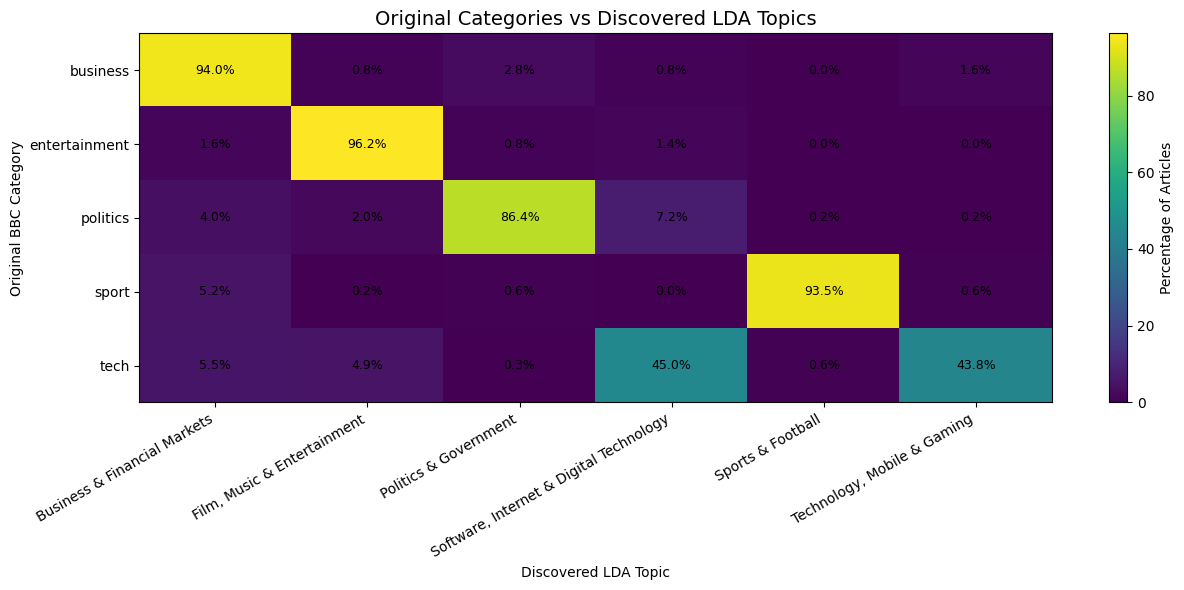


TOPIC vs CATEGORY ANALYSIS COMPLETED


In [15]:
# ============================================================
# NewsTopic-AI
# Step 13: Topic vs Original Category Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("TOPIC vs ORIGINAL CATEGORY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Cross-tabulation: article counts
# ------------------------------------------------------------

topic_category_counts = pd.crosstab(
    df["category"],
    df["dominant_topic_label"]
)

# ------------------------------------------------------------
# Cross-tabulation: row percentages
# Shows how each original category is distributed
# across discovered LDA topics.
# ------------------------------------------------------------

topic_category_percentages = pd.crosstab(
    df["category"],
    df["dominant_topic_label"],
    normalize="index"
) * 100

print("\n" + "=" * 70)
print("ARTICLE COUNTS")
print("=" * 70)

display(topic_category_counts)

print("\n" + "=" * 70)
print("CATEGORY DISTRIBUTION ACROSS DISCOVERED TOPICS (%)")
print("=" * 70)

display(
    topic_category_percentages.style.format(
        "{:.2f}%"
    )
)

# ------------------------------------------------------------
# Dominant discovered topic for each original category
# ------------------------------------------------------------

category_alignment = []

for category in topic_category_percentages.index:

    dominant_topic = (
        topic_category_percentages
        .loc[category]
        .idxmax()
    )

    dominant_percentage = (
        topic_category_percentages
        .loc[category]
        .max()
    )

    category_alignment.append({
        "original_category": category,
        "dominant_discovered_topic": dominant_topic,
        "alignment_percentage": dominant_percentage
    })

category_alignment = pd.DataFrame(
    category_alignment
)

print("\n" + "=" * 70)
print("CATEGORY → DOMINANT DISCOVERED TOPIC")
print("=" * 70)

display(
    category_alignment.style.format({
        "alignment_percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.imshow(
    topic_category_percentages.values,
    aspect="auto"
)

plt.colorbar(
    label="Percentage of Articles"
)

plt.xticks(
    range(len(topic_category_percentages.columns)),
    topic_category_percentages.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(topic_category_percentages.index)),
    topic_category_percentages.index
)

plt.title(
    "Original Categories vs Discovered LDA Topics",
    fontsize=14
)

plt.xlabel("Discovered LDA Topic")
plt.ylabel("Original BBC Category")

# Add percentages inside cells
for i in range(
    topic_category_percentages.shape[0]
):
    for j in range(
        topic_category_percentages.shape[1]
    ):
        value = topic_category_percentages.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("TOPIC vs CATEGORY ANALYSIS COMPLETED")
print("=" * 70)

TOP WORDS PER DISCOVERED TOPIC

TOP 10 WORDS PER TOPIC

Topic 1: Film, Music & Entertainment


,rank,word,weight
0,1,film,0.0107
1,2,best,0.0070
2,3,show,0.0069
3,4,world,0.0059
4,5,award,0.0058
5,6,music,0.0047
6,7,star,0.0041
7,8,band,0.0038
8,9,day,0.0038
9,10,top,0.0036



Topic 2: Technology, Mobile & Gaming


,rank,word,weight
10,1,game,0.0265
11,2,mobile,0.0147
12,3,phone,0.0110
13,4,technology,0.0104
14,5,video,0.0059
15,6,market,0.0056
16,7,player,0.0049
17,8,used,0.0048
18,9,digital,0.0047
19,10,play,0.0045



Topic 3: Politics & Government


...

,rank,word,weight
30,1,club,0.0076
31,2,win,0.0075
32,3,game,0.0069
33,4,england,0.0068
34,5,player,0.0052
35,6,final,0.0049
36,7,side,0.0047
37,8,team,0.0044
38,9,play,0.0044
39,10,season,0.0042



Topic 5: Software, Internet & Digital Technology


,rank,word,weight
40,1,software,0.0072
41,2,patent,0.0070
42,3,use,0.0054
43,4,computer,0.0054
44,5,online,0.0053
45,6,broadband,0.0053
46,7,network,0.0052
47,8,lord,0.0051
48,9,machine,0.0050
49,10,many,0.0049



Topic 6: Business & Financial Markets


,rank,word,weight
50,1,company,0.0083
51,2,firm,0.0072
52,3,market,0.0062
53,4,month,0.0055
54,5,sale,0.0054
55,6,share,0.0052
56,7,price,0.0044
57,8,business,0.0043
58,9,analyst,0.0041
59,10,bank,0.0036


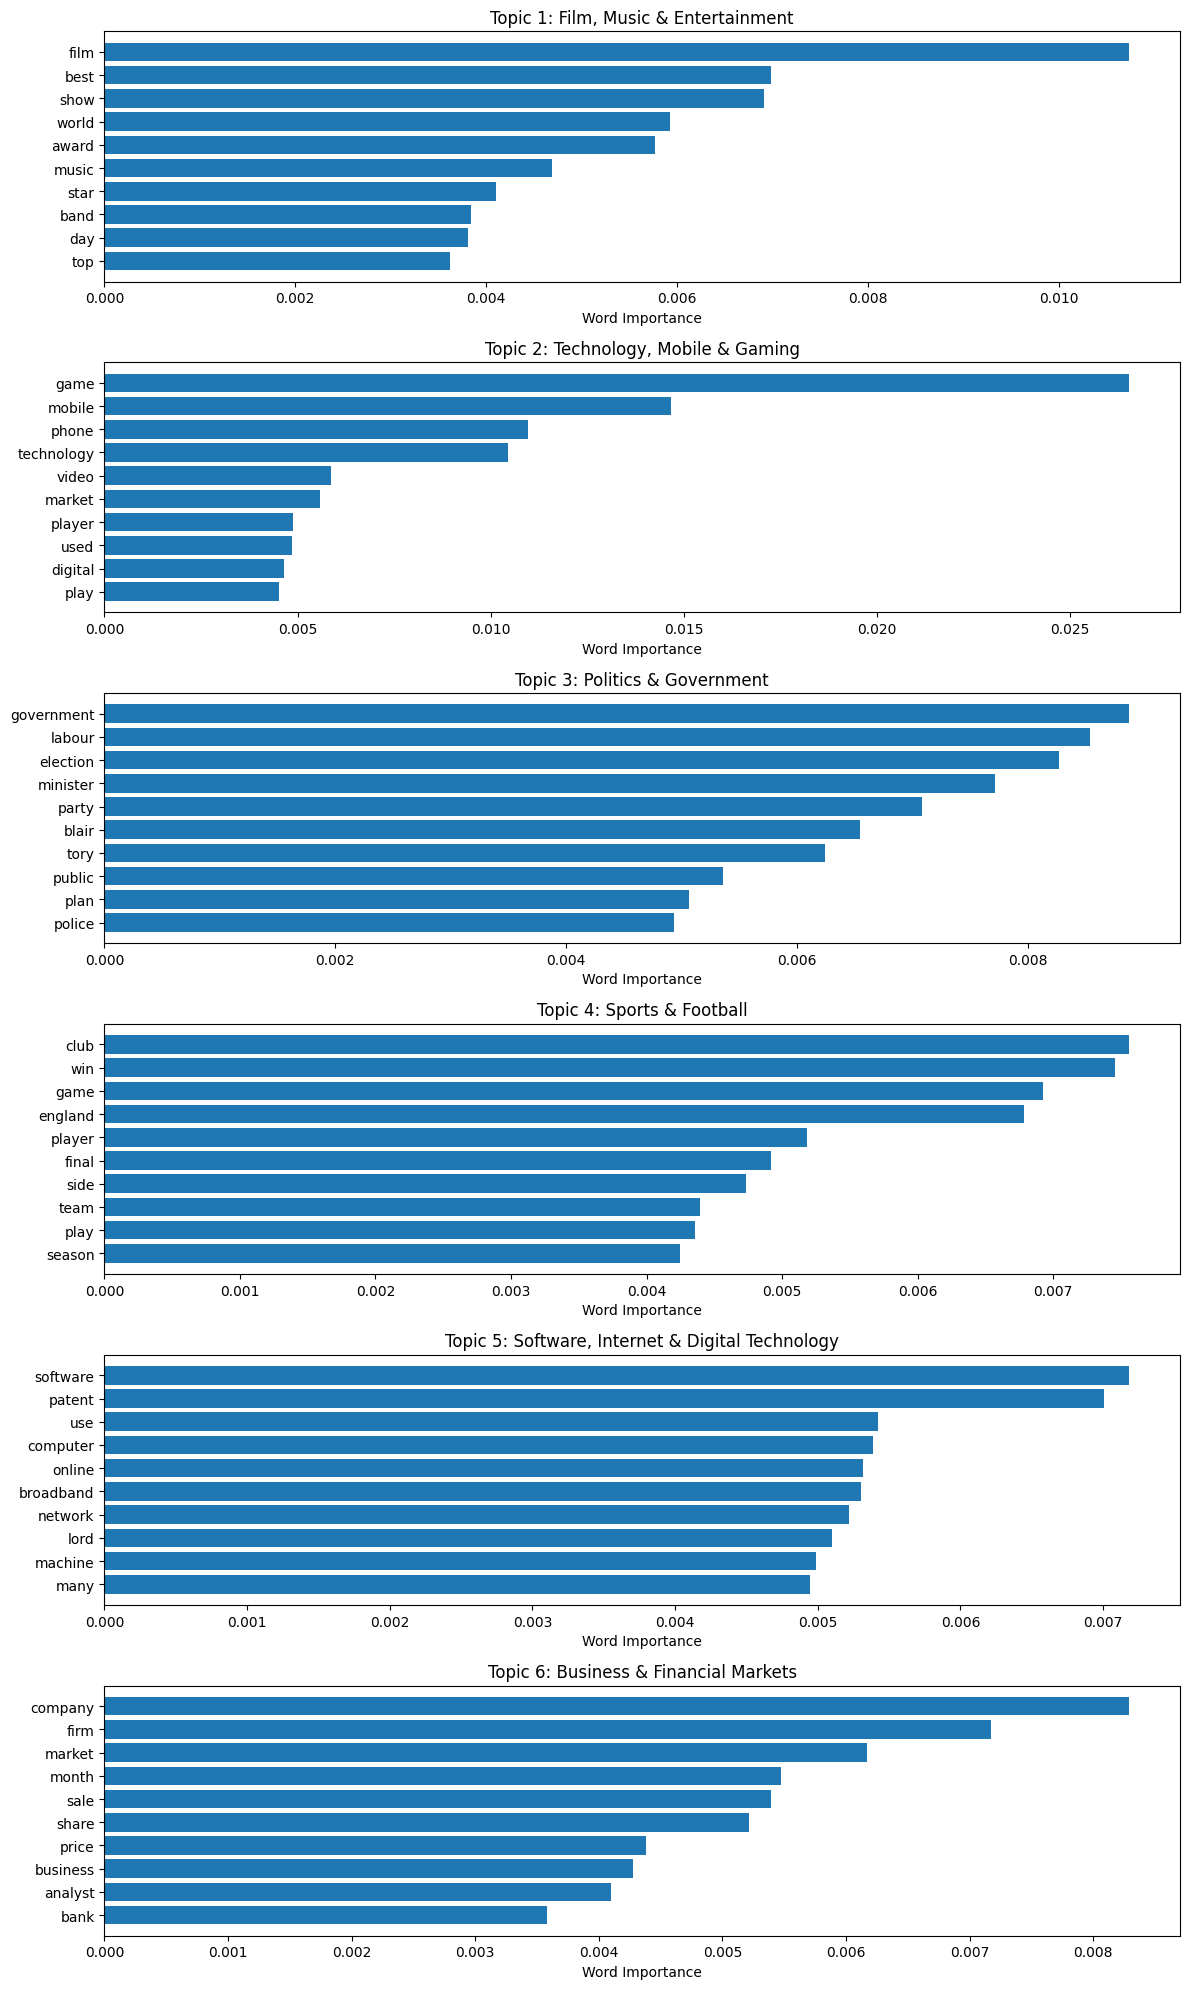


TOP WORD ANALYSIS COMPLETED


In [16]:
# ============================================================
# NewsTopic-AI
# Step 14: Top Words per Topic
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("TOP WORDS PER DISCOVERED TOPIC")
print("=" * 70)

# ------------------------------------------------------------
# Extract top words and their weights
# ------------------------------------------------------------

topic_word_data = []

for topic_id in range(refined_best_num_topics):

    topic_words = final_lda_model.show_topic(
        topic_id,
        topn=10
    )

    for rank, (word, weight) in enumerate(
        topic_words,
        start=1
    ):
        topic_word_data.append({
            "topic_id": topic_id + 1,
            "topic_label": topic_labels[topic_id],
            "rank": rank,
            "word": word,
            "weight": weight
        })

topic_word_df = pd.DataFrame(
    topic_word_data
)

# ------------------------------------------------------------
# Display extracted words
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 10 WORDS PER TOPIC")
print("=" * 70)

for topic_id in range(1, refined_best_num_topics + 1):

    topic_rows = topic_word_df[
        topic_word_df["topic_id"] == topic_id
    ]

    topic_label = topic_rows["topic_label"].iloc[0]

    print(f"\nTopic {topic_id}: {topic_label}")

    display(
        topic_rows[
            ["rank", "word", "weight"]
        ].style.format({
            "weight": "{:.4f}"
        })
    )

# ------------------------------------------------------------
# Multi-panel visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    refined_best_num_topics,
    1,
    figsize=(12, 20)
)

for topic_id, ax in enumerate(
    axes,
    start=1
):

    topic_rows = topic_word_df[
        topic_word_df["topic_id"] == topic_id
    ].sort_values(
        "weight",
        ascending=True
    )

    ax.barh(
        topic_rows["word"],
        topic_rows["weight"]
    )

    topic_label = topic_rows[
        "topic_label"
    ].iloc[0]

    ax.set_title(
        f"Topic {topic_id}: {topic_label}",
        fontsize=12
    )

    ax.set_xlabel(
        "Word Importance"
    )

    ax.set_ylabel(
        ""
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("TOP WORD ANALYSIS COMPLETED")
print("=" * 70)

In [17]:
# ============================================================
# NewsTopic-AI
# Step 15: Refined TF-IDF + NMF Topic Modeling
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import pandas as pd
import numpy as np

print("=" * 70)
print("NMF TOPIC MODELING")
print("=" * 70)

# ------------------------------------------------------------
# Create refined TF-IDF matrix
# ------------------------------------------------------------

refined_tfidf_vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.90,
    max_features=10000,
    ngram_range=(1, 2)
)

refined_tfidf_matrix = refined_tfidf_vectorizer.fit_transform(
    df["refined_text"]
)

print("\nRefined TF-IDF Matrix Shape:")
print(refined_tfidf_matrix.shape)

print(
    f"Refined TF-IDF Vocabulary Size: "
    f"{len(refined_tfidf_vectorizer.vocabulary_):,}"
)

# ------------------------------------------------------------
# Test multiple topic counts
# ------------------------------------------------------------

nmf_models = {}
nmf_results = []

topic_range = range(5, 11)

for n_topics in topic_range:

    print(
        f"\nTraining NMF with "
        f"{n_topics} topics..."
    )

    nmf_model = NMF(
        n_components=n_topics,
        init="nndsvda",
        random_state=42,
        max_iter=500
    )

    nmf_model.fit(
        refined_tfidf_matrix
    )

    reconstruction_error = (
        nmf_model.reconstruction_err_
    )

    nmf_models[n_topics] = nmf_model

    nmf_results.append({
        "n_topics": n_topics,
        "reconstruction_error": reconstruction_error
    })

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

nmf_results_df = pd.DataFrame(
    nmf_results
)

print("\n" + "=" * 70)
print("NMF TOPIC NUMBER COMPARISON")
print("=" * 70)

display(
    nmf_results_df.style.format({
        "reconstruction_error": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Select model with lowest reconstruction error
# ------------------------------------------------------------

nmf_best_num_topics = (
    nmf_results_df.loc[
        nmf_results_df["reconstruction_error"].idxmin(),
        "n_topics"
    ]
)

nmf_best_num_topics = int(
    nmf_best_num_topics
)

final_nmf_model = nmf_models[
    nmf_best_num_topics
]

print("\n" + "=" * 70)
print("BEST NMF MODEL")
print("=" * 70)

print(
    f"Best number of topics: "
    f"{nmf_best_num_topics}"
)

print(
    f"Reconstruction error: "
    f"{final_nmf_model.reconstruction_err_:.4f}"
)

print("\n" + "=" * 70)
print("NMF TRAINING COMPLETED")
print("=" * 70)

NMF TOPIC MODELING

Refined TF-IDF Matrix Shape:
(2126, 10000)
Refined TF-IDF Vocabulary Size: 10,000

Training NMF with 5 topics...

Training NMF with 6 topics...

Training NMF with 7 topics...

Training NMF with 8 topics...

Training NMF with 9 topics...

Training NMF with 10 topics...

NMF TOPIC NUMBER COMPARISON


,n_topics,reconstruction_error
0,5,44.6431
1,6,44.5219
2,7,44.4083
3,8,44.3003
4,9,44.1902
5,10,44.0819



BEST NMF MODEL
Best number of topics: 10
Reconstruction error: 44.0819

NMF TRAINING COMPLETED


In [18]:
# ============================================================
# NewsTopic-AI
# Step 16: NMF Topic Interpretation
# ============================================================

print("=" * 70)
print("NMF TOPIC INTERPRETATION")
print("=" * 70)

# ------------------------------------------------------------
# Reverse vocabulary mapping
# ------------------------------------------------------------

feature_names = (
    refined_tfidf_vectorizer
    .get_feature_names_out()
)

# ------------------------------------------------------------
# Extract top words for each NMF topic
# ------------------------------------------------------------

nmf_topic_word_data = []

for topic_id, topic_weights in enumerate(
    final_nmf_model.components_
):

    top_indices = topic_weights.argsort()[
        ::-1
    ][:15]

    for rank, word_index in enumerate(
        top_indices,
        start=1
    ):

        nmf_topic_word_data.append({
            "topic_id": topic_id + 1,
            "rank": rank,
            "word": feature_names[word_index],
            "weight": topic_weights[word_index]
        })

nmf_topic_word_df = pd.DataFrame(
    nmf_topic_word_data
)

# ------------------------------------------------------------
# Display topics
# ------------------------------------------------------------

for topic_id in range(
    1,
    nmf_best_num_topics + 1
):

    topic_rows = nmf_topic_word_df[
        nmf_topic_word_df["topic_id"] == topic_id
    ]

    print(
        f"\nTopic {topic_id}"
    )

    display(
        topic_rows[
            ["rank", "word", "weight"]
        ].style.format({
            "weight": "{:.4f}"
        })
    )

print("\n" + "=" * 70)
print("NMF TOPIC INTERPRETATION COMPLETED")
print("=" * 70)

NMF TOPIC INTERPRETATION

Topic 1


,rank,word,weight
0,1,england,1.1331
1,2,wale,0.7757
2,3,ireland,0.6756
3,4,rugby,0.5885
4,5,robinson,0.5724
5,6,six nation,0.5474
6,7,game,0.5248
7,8,france,0.5180
8,9,nation,0.4917
9,10,six,0.4739



Topic 2


,rank,word,weight
15,1,labour,0.6862
16,2,election,0.6399
17,3,party,0.5043
18,4,blair,0.4911
19,5,brown,0.4606
20,6,tory,0.4360
21,7,tax,0.4088
22,8,howard,0.3078
23,9,chancellor,0.2667
24,10,prime minister,0.2437



Topic 3


...


Topic 9


,rank,word,weight
120,1,game,0.4528
121,2,club,0.3945
122,3,chelsea,0.3581
123,4,league,0.2554
124,5,liverpool,0.2552
125,6,united,0.2455
126,7,arsenal,0.2452
127,8,player,0.2250
128,9,goal,0.1953
129,10,mourinho,0.1949



Topic 10


,rank,word,weight
135,1,music,0.5652
136,2,band,0.5045
137,3,album,0.4491
138,4,chart,0.3582
139,5,song,0.3177
140,6,single,0.2661
141,7,show,0.2427
142,8,rock,0.2214
143,9,number,0.2019
144,10,award,0.1976



NMF TOPIC INTERPRETATION COMPLETED


In [19]:
# ============================================================
# NewsTopic-AI
# Step 17: NMF Document Topic Assignment
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("NMF DOCUMENT TOPIC ASSIGNMENT")
print("=" * 70)

# ------------------------------------------------------------
# Transform documents into NMF topic space
# ------------------------------------------------------------

nmf_document_matrix = final_nmf_model.transform(
    refined_tfidf_matrix
)

print(
    f"\nNMF Document-Topic Matrix Shape: "
    f"{nmf_document_matrix.shape}"
)

# ------------------------------------------------------------
# Dominant topic for each document
# ------------------------------------------------------------

nmf_dominant_topic = (
    np.argmax(
        nmf_document_matrix,
        axis=1
    )
)

nmf_dominant_weight = (
    np.max(
        nmf_document_matrix,
        axis=1
    )
)

# ------------------------------------------------------------
# Store NMF topic information
# ------------------------------------------------------------

df["nmf_dominant_topic"] = (
    nmf_dominant_topic + 1
)

df["nmf_dominant_weight"] = (
    nmf_dominant_weight
)

# ------------------------------------------------------------
# Create readable NMF topic labels
# ------------------------------------------------------------

nmf_topic_labels = {
    1: "Rugby & Six Nations",
    2: "UK Elections & Political Parties",
    3: "Economy & Financial Markets",
    4: "Film & Awards",
    5: "Mobile, Broadband & Technology",
    6: "Law, Government & Human Rights",
    7: "Tennis & International Sports",
    8: "Russian Oil & Corporate Affairs",
    9: "Football Clubs & Leagues",
    10: "Music, Bands & Albums"
}

df["nmf_dominant_topic_label"] = (
    df["nmf_dominant_topic"]
    .map(nmf_topic_labels)
)

# ------------------------------------------------------------
# Validate assignments
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NMF TOPIC ASSIGNMENT VALIDATION")
print("=" * 70)

print(
    f"Documents: {len(df):,}"
)

print(
    f"Topics: {nmf_best_num_topics}"
)

print(
    "Missing topic assignments:",
    df["nmf_dominant_topic"].isna().sum()
)

print(
    "Missing topic labels:",
    df["nmf_dominant_topic_label"].isna().sum()
)

# ------------------------------------------------------------
# Topic distribution
# ------------------------------------------------------------

nmf_topic_summary = (
    df.groupby(
        [
            "nmf_dominant_topic",
            "nmf_dominant_topic_label"
        ],
        as_index=False
    )
    .agg(
        article_count=(
            "nmf_dominant_topic",
            "size"
        ),
        average_weight=(
            "nmf_dominant_weight",
            "mean"
        )
    )
)

nmf_topic_summary["percentage"] = (
    nmf_topic_summary["article_count"]
    / len(df)
    * 100
)

nmf_topic_summary = (
    nmf_topic_summary
    .sort_values("nmf_dominant_topic")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("NMF TOPIC DISTRIBUTION")
print("=" * 70)

display(
    nmf_topic_summary.style.format({
        "average_weight": "{:.4f}",
        "percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Preview assignments
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAMPLE NMF ASSIGNMENTS")
print("=" * 70)

display(
    df[
        [
            "category",
            "nmf_dominant_topic",
            "nmf_dominant_topic_label",
            "nmf_dominant_weight"
        ]
    ].head(10).style.format({
        "nmf_dominant_weight": "{:.4f}"
    })
)

print("\n" + "=" * 70)
print("NMF DOCUMENT TOPIC ASSIGNMENT COMPLETED")
print("=" * 70)

NMF DOCUMENT TOPIC ASSIGNMENT

NMF Document-Topic Matrix Shape: (2126, 10)

NMF TOPIC ASSIGNMENT VALIDATION
Documents: 2,126
Topics: 10
Missing topic assignments: 0
Missing topic labels: 0

NMF TOPIC DISTRIBUTION


,nmf_dominant_topic,nmf_dominant_topic_label,article_count,average_weight,percentage
0,1,Rugby & Six Nations,128,0.0996,6.02%
1,2,UK Elections & Political Parties,214,0.1517,10.07%
2,3,Economy & Financial Markets,357,0.1011,16.79%
3,4,Film & Awards,190,0.1563,8.94%
4,5,"Mobile, Broadband & Technology",302,0.1186,14.21%
5,6,"Law, Government & Human Rights",266,0.0944,12.51%
6,7,Tennis & International Sports,192,0.1566,9.03%
7,8,Russian Oil & Corporate Affairs,67,0.1519,3.15%
8,9,Football Clubs & Leagues,236,0.1411,11.10%
9,10,"Music, Bands & Albums",174,0.1335,8.18%



SAMPLE NMF ASSIGNMENTS


,category,nmf_dominant_topic,nmf_dominant_topic_label,nmf_dominant_weight
0,sport,1,Rugby & Six Nations,0.0943
1,business,3,Economy & Financial Markets,0.0875
2,entertainment,10,"Music, Bands & Albums",0.1393
3,business,3,Economy & Financial Markets,0.1424
4,tech,5,"Mobile, Broadband & Technology",0.1782
5,politics,6,"Law, Government & Human Rights",0.1555
6,entertainment,10,"Music, Bands & Albums",0.2101
7,entertainment,10,"Music, Bands & Albums",0.0441
8,politics,2,UK Elections & Political Parties,0.1623
9,business,3,Economy & Financial Markets,0.1023



NMF DOCUMENT TOPIC ASSIGNMENT COMPLETED


In [20]:
# ============================================================
# NewsTopic-AI
# Step 18: NMF vs Original Category Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("NMF vs ORIGINAL CATEGORY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Cross-tabulation
# ------------------------------------------------------------

nmf_category_counts = pd.crosstab(
    df["category"],
    df["nmf_dominant_topic_label"]
)

print("\n" + "=" * 70)
print("NMF ARTICLE COUNTS BY ORIGINAL CATEGORY")
print("=" * 70)

display(
    nmf_category_counts
)

# ------------------------------------------------------------
# Row-normalized percentages
# ------------------------------------------------------------

nmf_category_percentages = pd.crosstab(
    df["category"],
    df["nmf_dominant_topic_label"],
    normalize="index"
) * 100

print("\n" + "=" * 70)
print("NMF CATEGORY DISTRIBUTION ACROSS TOPICS (%)")
print("=" * 70)

display(
    nmf_category_percentages.style.format(
        "{:.2f}%"
    )
)

# ------------------------------------------------------------
# Dominant NMF topic per original category
# ------------------------------------------------------------

nmf_category_alignment = []

for category in nmf_category_percentages.index:

    dominant_topic = (
        nmf_category_percentages
        .loc[category]
        .idxmax()
    )

    dominant_percentage = (
        nmf_category_percentages
        .loc[category]
        .max()
    )

    nmf_category_alignment.append({
        "original_category": category,
        "dominant_nmf_topic": dominant_topic,
        "alignment_percentage": dominant_percentage
    })

nmf_category_alignment = pd.DataFrame(
    nmf_category_alignment
)

print("\n" + "=" * 70)
print("CATEGORY → DOMINANT NMF TOPIC")
print("=" * 70)

display(
    nmf_category_alignment.style.format({
        "alignment_percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Average best-topic alignment
# ------------------------------------------------------------

average_nmf_alignment = (
    nmf_category_alignment[
        "alignment_percentage"
    ].mean()
)

print("\n" + "=" * 70)
print("NMF CATEGORY ALIGNMENT SUMMARY")
print("=" * 70)

print(
    f"Average category alignment: "
    f"{average_nmf_alignment:.2f}%"
)

print("\n" + "=" * 70)
print("NMF CATEGORY ANALYSIS COMPLETED")
print("=" * 70)

NMF vs ORIGINAL CATEGORY ANALYSIS

NMF ARTICLE COUNTS BY ORIGINAL CATEGORY


nmf_dominant_topic_label,Economy & Financial Markets,Film & Awards,Football Clubs & Leagues,"Law, Government & Human Rights","Mobile, Broadband & Technology","Music, Bands & Albums",Rugby & Six Nations,Russian Oil & Corporate Affairs,Tennis & International Sports,UK Elections & Political Parties
category,,,,,,,,,,
business,349,1,14,51,14,3,0,67,0,4
entertainment,3,182,0,16,2,164,0,0,2,0
politics,4,0,2,183,2,0,2,0,2,208
sport,0,0,191,1,0,0,126,0,185,1
tech,1,7,29,15,284,7,0,0,3,1



NMF CATEGORY DISTRIBUTION ACROSS TOPICS (%)


nmf_dominant_topic_label,Economy & Financial Markets,Film & Awards,Football Clubs & Leagues,"Law, Government & Human Rights","Mobile, Broadband & Technology","Music, Bands & Albums",Rugby & Six Nations,Russian Oil & Corporate Affairs,Tennis & International Sports,UK Elections & Political Parties
category,,,,,,,,,,
business,69.38%,0.20%,2.78%,10.14%,2.78%,0.60%,0.00%,13.32%,0.00%,0.80%
entertainment,0.81%,49.32%,0.00%,4.34%,0.54%,44.44%,0.00%,0.00%,0.54%,0.00%
politics,0.99%,0.00%,0.50%,45.41%,0.50%,0.00%,0.50%,0.00%,0.50%,51.61%
sport,0.00%,0.00%,37.90%,0.20%,0.00%,0.00%,25.00%,0.00%,36.71%,0.20%
tech,0.29%,2.02%,8.36%,4.32%,81.84%,2.02%,0.00%,0.00%,0.86%,0.29%



CATEGORY → DOMINANT NMF TOPIC


,original_category,dominant_nmf_topic,alignment_percentage
0,business,Economy & Financial Markets,69.38%
1,entertainment,Film & Awards,49.32%
2,politics,UK Elections & Political Parties,51.61%
3,sport,Football Clubs & Leagues,37.90%
4,tech,"Mobile, Broadband & Technology",81.84%



NMF CATEGORY ALIGNMENT SUMMARY
Average category alignment: 58.01%

NMF CATEGORY ANALYSIS COMPLETED


In [21]:
# ============================================================
# NewsTopic-AI
# Step 19: Final LDA vs NMF Comparison
# ============================================================

print("=" * 70)
print("FINAL LDA vs NMF COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Calculate LDA category alignment
# ------------------------------------------------------------

lda_average_alignment = (
    category_alignment["alignment_percentage"].mean()
)

# ------------------------------------------------------------
# NMF category alignment
# ------------------------------------------------------------

nmf_average_alignment = (
    nmf_category_alignment["alignment_percentage"].mean()
)

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "LDA",
        "NMF"
    ],
    "Number of Topics": [
        refined_best_num_topics,
        nmf_best_num_topics
    ],
    "Selection Criterion": [
        "Coherence",
        "Reconstruction Error"
    ],
    "Primary Score": [
        refined_best_coherence,
        final_nmf_model.reconstruction_err_
    ],
    "Average Category Alignment (%)": [
        lda_average_alignment,
        nmf_average_alignment
    ]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    model_comparison.style.format({
        "Primary Score": "{:.4f}",
        "Average Category Alignment (%)": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Key findings
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

print(
    f"LDA topics: "
    f"{refined_best_num_topics}"
)

print(
    f"LDA coherence: "
    f"{refined_best_coherence:.4f}"
)

print(
    f"LDA average category alignment: "
    f"{lda_average_alignment:.2f}%"
)

print()

print(
    f"NMF topics: "
    f"{nmf_best_num_topics}"
)

print(
    f"NMF reconstruction error: "
    f"{final_nmf_model.reconstruction_err_:.4f}"
)

print(
    f"NMF average category alignment: "
    f"{nmf_average_alignment:.2f}%"
)

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(
    "LDA produced a more compact topic structure with "
    "strong alignment to the original BBC categories."
)

print(
    "NMF produced a more fine-grained topic structure, "
    "separating several original categories into meaningful "
    "subtopics such as rugby, football, tennis, film, music, "
    "UK elections, law, and Russian oil."
)

print(
    "The two models therefore provide complementary views "
    "of the same news corpus."
)

print("\n" + "=" * 70)
print("LDA vs NMF COMPARISON COMPLETED")
print("=" * 70)

FINAL LDA vs NMF COMPARISON

MODEL COMPARISON


,Model,Number of Topics,Selection Criterion,Primary Score,Average Category Alignment (%)
0,LDA,6,Coherence,0.5987,83.00%
1,NMF,10,Reconstruction Error,44.0819,58.01%



KEY FINDINGS
LDA topics: 6
LDA coherence: 0.5987
LDA average category alignment: 83.00%

NMF topics: 10
NMF reconstruction error: 44.0819
NMF average category alignment: 58.01%

INTERPRETATION
LDA produced a more compact topic structure with strong alignment to the original BBC categories.
NMF produced a more fine-grained topic structure, separating several original categories into meaningful subtopics such as rugby, football, tennis, film, music, UK elections, law, and Russian oil.
The two models therefore provide complementary views of the same news corpus.

LDA vs NMF COMPARISON COMPLETED


In [22]:
# ============================================================
# NewsTopic-AI
# Step 20: Export Analysis Results
# ============================================================

from pathlib import Path

print("=" * 70)
print("EXPORTING MODELING RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Create output directories
# ------------------------------------------------------------

output_dir = Path("newstopic_outputs")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Export article-level topic assignments
# ------------------------------------------------------------

article_results = df[
    [
        "text",
        "category",
        "dominant_topic",
        "dominant_topic_label",
        "dominant_topic_probability",
        "nmf_dominant_topic",
        "nmf_dominant_topic_label",
        "nmf_dominant_weight"
    ]
].copy()

article_results.to_csv(
    output_dir / "article_topic_results.csv",
    index=False
)

# ------------------------------------------------------------
# Export LDA topic summary
# ------------------------------------------------------------

topic_summary.to_csv(
    output_dir / "lda_topic_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Export LDA top words
# ------------------------------------------------------------

topic_word_df.to_csv(
    output_dir / "lda_topic_words.csv",
    index=False
)

# ------------------------------------------------------------
# Export NMF topic summary
# ------------------------------------------------------------

nmf_topic_summary.to_csv(
    output_dir / "nmf_topic_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Export NMF top words
# ------------------------------------------------------------

nmf_topic_word_df.to_csv(
    output_dir / "nmf_topic_words.csv",
    index=False
)

# ------------------------------------------------------------
# Export model comparison
# ------------------------------------------------------------

model_comparison.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# Export LDA category alignment
# ------------------------------------------------------------

category_alignment.to_csv(
    output_dir / "lda_category_alignment.csv",
    index=False
)

# ------------------------------------------------------------
# Export NMF category alignment
# ------------------------------------------------------------

nmf_category_alignment.to_csv(
    output_dir / "nmf_category_alignment.csv",
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("\nExported files:")

for file_path in sorted(
    output_dir.iterdir()
):

    print(
        f"- {file_path.name}"
    )

print("\n" + "=" * 70)
print("EXPORT COMPLETED")
print("=" * 70)

EXPORTING MODELING RESULTS

Exported files:
- article_topic_results.csv
- lda_category_alignment.csv
- lda_topic_summary.csv
- lda_topic_words.csv
- model_comparison.csv
- nmf_category_alignment.csv
- nmf_topic_summary.csv
- nmf_topic_words.csv

EXPORT COMPLETED


In [23]:
# ============================================================
# NewsTopic-AI
# Step 23: Export Models and NLP Artifacts
# ============================================================

import os
import pickle
import joblib
import json

print("=" * 70)
print("EXPORTING MODEL ARTIFACTS")
print("=" * 70)

# ------------------------------------------------------------
# Create artifact directory
# ------------------------------------------------------------

os.makedirs("artifacts", exist_ok=True)

# ------------------------------------------------------------
# Save LDA model and dictionary
# ------------------------------------------------------------

final_lda_model.save(
    "artifacts/final_lda_model"
)

with open(
    "artifacts/refined_dictionary.pkl",
    "wb"
) as f:
    pickle.dump(
        refined_dictionary,
        f
    )

# ------------------------------------------------------------
# Save LDA topic labels
# ------------------------------------------------------------

with open(
    "artifacts/lda_topic_labels.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        topic_labels,
        f,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# Save NMF model and TF-IDF vectorizer
# ------------------------------------------------------------

joblib.dump(
    final_nmf_model,
    "artifacts/final_nmf_model.joblib"
)

joblib.dump(
    refined_tfidf_vectorizer,
    "artifacts/refined_tfidf_vectorizer.joblib"
)

# ------------------------------------------------------------
# Save NMF topic labels
# ------------------------------------------------------------

with open(
    "artifacts/nmf_topic_labels.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        nmf_topic_labels,
        f,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# Validate exported files
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXPORTED ARTIFACTS")
print("=" * 70)

for filename in sorted(os.listdir("artifacts")):

    filepath = os.path.join(
        "artifacts",
        filename
    )

    size_kb = (
        os.path.getsize(filepath)
        / 1024
    )

    print(
        f"{filename:<40} "
        f"{size_kb:,.1f} KB"
    )

print("\n" + "=" * 70)
print("MODEL ARTIFACT EXPORT COMPLETED")
print("=" * 70)

EXPORTING MODEL ARTIFACTS

EXPORTED ARTIFACTS
final_lda_model                          48.5 KB
final_lda_model.expElogbeta.npy          252.5 KB
final_lda_model.id2word                  326.3 KB
final_lda_model.state                    295.0 KB
final_nmf_model.joblib                   781.9 KB
lda_topic_labels.json                    0.2 KB
nmf_topic_labels.json                    0.4 KB
refined_dictionary.pkl                   326.3 KB
refined_tfidf_vectorizer.joblib          376.5 KB

MODEL ARTIFACT EXPORT COMPLETED


In [24]:
from pathlib import Path
import shutil

# Locate exported model artifacts
artifact_files = [
    "final_lda_model",
    "final_lda_model.expElogbeta.npy",
    "final_lda_model.id2word",
    "final_lda_model.state",
    "final_nmf_model.joblib",
    "lda_topic_labels.json",
    "nmf_topic_labels.json",
    "refined_dictionary.pkl",
    "refined_tfidf_vectorizer.joblib",
]

# Search for the artifacts in the current Colab workspace
search_roots = [Path("."), Path("/content")]

found_files = {}

for filename in artifact_files:
    found = None

    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            found = matches[0]
            break

    if found:
        found_files[filename] = found
    else:
        print(f"NOT FOUND: {filename}")

print("\n" + "=" * 70)
print("FOUND ARTIFACTS")
print("=" * 70)

for filename, path in found_files.items():
    size_kb = path.stat().st_size / 1024
    print(f"{filename:<45} {size_kb:>10.1f} KB")

# Create a clean export directory
export_dir = Path("/content/NewsTopic-AI-models")
export_dir.mkdir(exist_ok=True)

# Copy artifacts while preserving filenames
for filename, source_path in found_files.items():
    shutil.copy2(source_path, export_dir / filename)

# Create ZIP
zip_path = shutil.make_archive(
    "/content/NewsTopic-AI-models",
    "zip",
    export_dir
)

print("\n" + "=" * 70)
print("EXPORT READY")
print("=" * 70)
print(f"Files exported: {len(found_files)}/{len(artifact_files)}")
print(f"ZIP: {zip_path}")
print(f"Size: {Path(zip_path).stat().st_size / (1024 * 1024):.2f} MB")


FOUND ARTIFACTS
final_lda_model                                     48.5 KB
final_lda_model.expElogbeta.npy                    252.5 KB
final_lda_model.id2word                            326.3 KB
final_lda_model.state                              295.0 KB
final_nmf_model.joblib                             781.9 KB
lda_topic_labels.json                                0.2 KB
nmf_topic_labels.json                                0.4 KB
refined_dictionary.pkl                             326.3 KB
refined_tfidf_vectorizer.joblib                    376.5 KB

EXPORT READY
Files exported: 9/9
ZIP: /content/NewsTopic-AI-models.zip
Size: 1.33 MB


In [25]:
from google.colab import files

files.download("/content/NewsTopic-AI-models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>